This notebook allows for testing our L-VQE algorithm for solving the Max-Cut problem on $3$-regular graph instances.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from simulator import QuimbSimulator
from src.maxcut import MaxCut
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE

In [2]:
SEED=562    # for reproducibility
np.random.seed(SEED)

N_NODES = 32

N_LAYERS=2
K_PER_LAYER=50
K_FINAL=300

SIMULATOR=SMO          # COBYLA or SMO

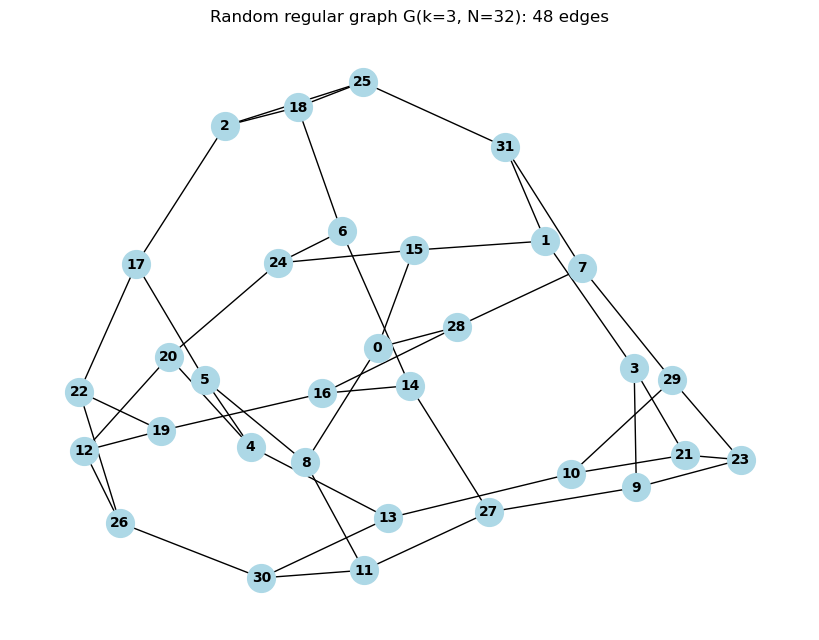

In [3]:
def get_random_graph(N: int, seed: int) -> nx.Graph:
    assert N % 2 == 0
    rng_graph = np.random.RandomState(seed)
    while True:
        G = nx.random_regular_graph(3, N, seed=rng_graph)
        if nx.is_connected(G):
            return G

G = get_random_graph(N_NODES, seed=SEED)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=SEED)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
    node_size=400, font_size=10, font_weight='bold')
plt.title(f"Random regular graph G(k=3, N={G.number_of_nodes()}): {G.number_of_edges()} edges")
plt.show()

In [4]:
problem = MaxCut(G, seed=SEED)
print(f"\nn_qubits: {problem.num_qubits}")
print(f"n_terms: {len(problem.hamiltonian_terms)}\n")

best_known = problem.best_known_value
print(f"best known cut value : {best_known}")
print(f"corresponding energy: {problem.cut_to_energy(best_known)}")



n_qubits: 31
n_terms: 48

best known cut value : 43.0
corresponding energy: 19.0


In [5]:
sim = QuimbSimulator()
lvqe = LayerVQE(
    problem=problem,
    simulator=sim,
    optimizer_class=SIMULATOR,
    n_layers=N_LAYERS,
    k_per_layer=K_PER_LAYER,
    k_final=K_FINAL,
    use_sampling=False,
    n_samples=1000,
    record_loss=True
)

result = lvqe.run()

print(f"\nFinal approximation ratio: {result['final_approx_ratio']:.4f}")

Starting L-VQE: 2 layers, 50 iter/layer, 300 final iter
Mode: exact expectation

Layer 0: 

Optimizer: SMO | max_iter=50


SMO: 100%|██████████| 50/50 [00:02<00:00, 17.61it/s, best_E=+14.0000]


layer 0: energy=+14.0000, approx_ratio=+0.8837

Layer 1 — 50 iterations (before convergence)
Optimizer: SMO | max_iter=50


SMO: 100%|██████████| 50/50 [00:04<00:00, 10.53it/s, best_E=+14.0000]


layer 1: energy=+14.0000, approx_ratio=+0.8837

Final layer — 300 iterations (final)
Optimizer: SMO | max_iter=300


SMO: 100%|██████████| 300/300 [00:38<00:00,  7.88it/s, best_E=+14.0000]

layer 2: energy=+14.0000, approx_ratio=+0.8837

Final approximation ratio: 0.8837


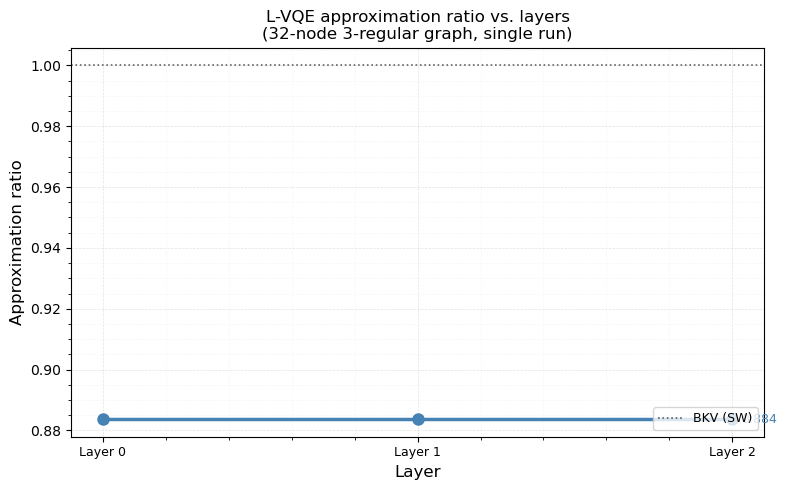

In [6]:
# plot 1: approx ratio vs. layers
layers = result['history']['layer']
ratios = [result['history']['approx_ratio'][l] for l in layers]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(layers, ratios, 'o-', color='steelblue', linewidth=2.5, markersize=8, zorder=3)

ax.annotate(
    f"{ratios[-1]:.3f}",
    xy=(layers[-1], ratios[-1]),
    xytext=(6, 0), textcoords="offset points",
    fontsize=9, color='steelblue', va='center',
)

ax.axhline(y=1.0, color='black', linestyle=':', linewidth=1.2, alpha=0.6, label=f"BKV ({'SW' if N_NODES > 20 else 'brute force'})")

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Approximation ratio', fontsize=12)
ax.set_title(
    f'L-VQE approximation ratio vs. layers\n'
    f'({N_NODES}-node 3-regular graph, single run)',
    fontsize=12,
)
ax.set_xticks(layers)
ax.set_xticklabels([f'Layer {l}' for l in layers], fontsize=9)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.35)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
fig.tight_layout()
plt.show()

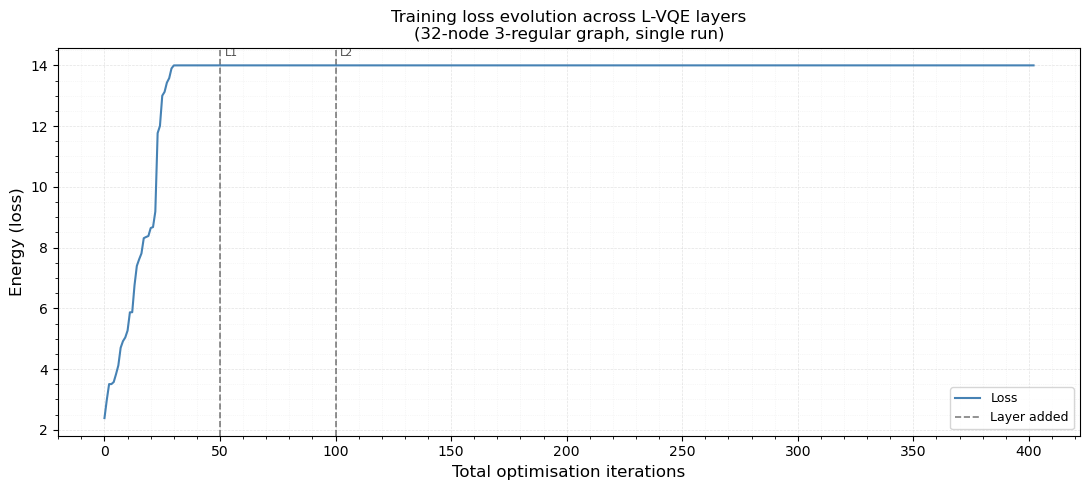

In [7]:
# plot 2: loss evolution across training
# NB: we defined Max-Cut as a maximization problem; hence energy/loss increases
fig, ax = plt.subplots(figsize=(11, 5))

optimizer_loss = result['history']['optimizer_loss']
continuous_loss = np.concatenate(optimizer_loss)

ax.plot(continuous_loss, color='steelblue', linewidth=1.5, zorder=3, label='Loss')

y_top = ax.get_ylim()[1]
for idx in range(1, N_LAYERS + 1):
    #when a new layer is added, its parameters are initialized to zero and hence evaluates to the identity
    #so the loss should not abruptly decrease (nor increase), which would have been the case if e.g. all parameters would have been re-initialized randomly
    x = K_PER_LAYER * idx
    ax.axvline(x=x, color='black', linestyle='--', linewidth=1.2, alpha=0.5,
               label='Layer added' if idx == 1 else '')
    ax.text(x + len(continuous_loss) * 0.005, y_top, f'L{idx}',
            fontsize=8, ha='left', va='top', color='black', alpha=0.7)

ax.set_xlabel('Total optimisation iterations', fontsize=12)
ax.set_ylabel('Energy (loss)', fontsize=12)
ax.set_title(
    f'Training loss evolution across L-VQE layers\n'
    f'({N_NODES}-node 3-regular graph, single run)',
    fontsize=12,
)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.35)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
fig.tight_layout()
plt.show()

In [8]:
bitstrings = sim.get_most_frequent_assignments(result['final_params'], result['final_ansatz'], problem=problem)

print(f"  Most frequent assignments (best known cut: {problem.best_known_value:.0f})")
for i, (assignment, proba) in enumerate(bitstrings, start=1):
    cut_value = problem.evaluate(assignment)
    approx_ratio = cut_value / problem.best_known_value
    marker = " ✓" if cut_value == problem.best_known_value else ""
    print(f"  #{i}  prob={proba:5.1f}%  cut={cut_value:.0f}  "
          f"energy={problem.cut_to_energy(cut_value):.1f}  ratio={approx_ratio:.4f}{marker}")

  Most frequent assignments (best known cut: 43)
  #1  prob=100.0%  cut=38  energy=14.0  ratio=0.8837
